In [ ]:
import os #Se importan librerias y se crean las instancias
os.environ['PYTHONHASHSEED']=str(1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use('seaborn-deep')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = 'Ubuntu'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.figsize'] = (12, 12)

pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 400)
import warnings
warnings.filterwarnings('ignore')
from pprint import pprint
#Se importan las herramientas para el machine learning
import sklearn.metrics as skm #Objeto para analizar metricas
import sklearn.model_selection as skms #Objeto para validacion
import sklearn.ensemble as ske #Objeto para el modelo Random Forest
import sklearn.tree as skt #Objeto para el modelo decision tree
import sklearn.preprocessing as skp #
import random
import os, shutil, re, string
import spacy
seed=100

In [ ]:
from google.colab import drive
drive.mount('/gdrive')
# Se enlaza el colab con google drive para traer al cuaderno los datos capturados por el sensor anteriormente

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [ ]:
# Se coloca el path hacia la carpeta que contiene los datos capturados
!ls '/gdrive/My Drive/practica6/datos/'

10.csv	1.csv  2.csv  3.csv  4.csv  5.csv  6.csv  7.csv  8.csv	9.csv


In [ ]:
DIR = '/gdrive/My Drive/practica6/datos/' #Se define la ruta donde estan los datos del sensor en archivos .CSV, se debe cambiar dependiendo de donde se hayan guardado estos datos en google drive
df = pd.DataFrame() #Se crea un dataframe vacio
for x in range(1,11): #Se recorre cada .CSV
    df_temp = pd.read_csv(os.path.join(DIR, str(x)+'.csv')) #El contenido de cada .CSV se carga en df_temp
    df_temp.columns = ['A','B','C','x','y','z','class'] #Se asignan nombres genéricos a cada columna sabiendo que A,B,C representan los datos de acelerometro y x,y,z los datos del giroscopio
    df_temp['person'] = x #Se crea una nueva columna llamada "person" que indica que indica a que persona, (persona 1 ó 2 ó 3.......) corresponden los datos
    df = pd.concat([df, df_temp], axis=0) #Junta los .CSV con los nombres de columnas y la columna persona uno debajo del otro para hacer un unico dataframe
print("Scanned",len(df.person.unique()),"participants recordings") #Muestra el número de personas a los que se les registraron los datos
df.tail() #Muestra las ultimas 5 filas del dataframe

Scanned 10 participants recordings


,A,B,C,x,y,z,class,person
4213,184,-1334,525,-25160,-501,13629,4,10
4214,-264,-1757,763,-13563,-272,9985,4,10
4215,-781,-3140,1320,-6589,663,8688,4,10
4216,-505,-1966,964,840,-1113,2546,4,10
4217,-331,940,-54,12394,-2053,-12818,4,10


In [ ]:
df.shape #Muesta el tamaño total de dataframe con todos los .CSV apilados

(41820, 8)

In [ ]:
index_label = dict() #Se crea un diccionario que relaciona números de clase con el nombre de la actividad.
index_label[0] = "None"
index_label[1] = "Caminar"
index_label[2] = "sentarse"
index_label[3] = "mover el torso"
index_label[4] = "saltar"

index_label.values()

dict_values(['None', 'Caminar', 'sentarse', 'mover el torso', 'saltar'])

In [ ]:
df.head() #Muestra las primeras 5 filas del dataframe

,A,B,C,x,y,z,class,person
0,-273,-78,194,-8209,-1143,11831,1,1
1,-73,41,89,-7782,-1408,13763,1,1
2,-73,-284,1,-8543,-1266,13596,1,1
3,48,-306,-79,-9315,-1725,12990,1,1
4,98,-130,-175,-11340,-2315,12269,1,1


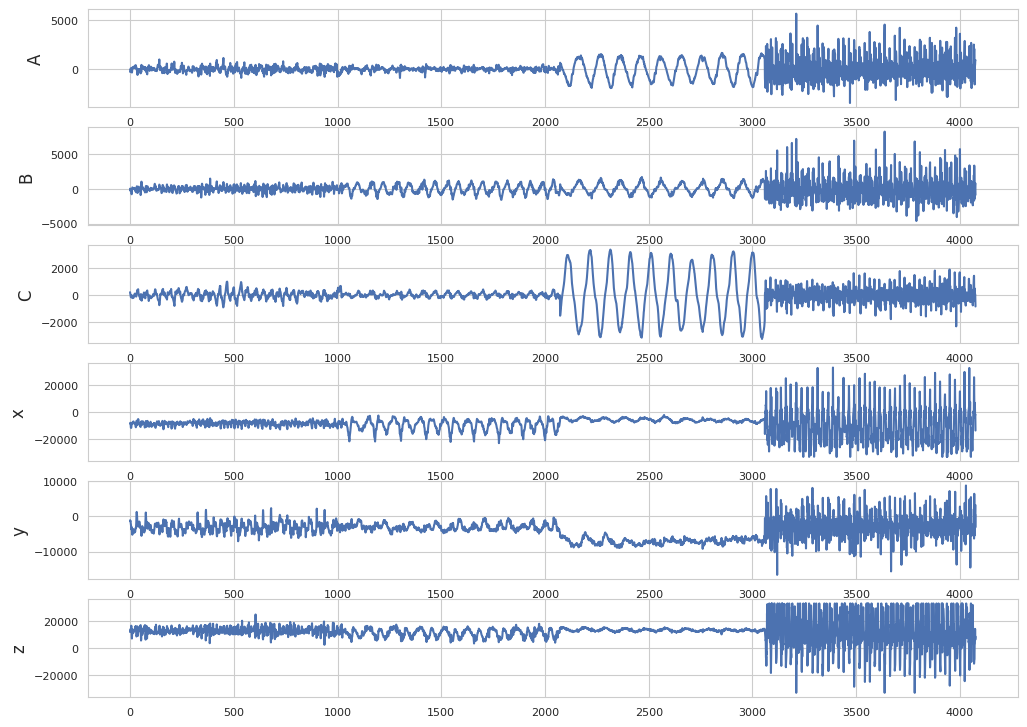

In [ ]:
def plotXYZ(df_plot, p): #Función para graficar las señales capturadas de cada variable respecto al tiempo (muestra)
    plt.figure()
    for col in range(6):#Se recorren las 6 señales
        plt.subplot(df_plot.shape[1], 1, col+1)#Para que las gráficas se apilen verticalmente
        sns.lineplot(data=df_plot,x=np.array(df_plot.index.tolist()), y=df_plot.iloc[:,col]) #Se define el numero de muestra en el eje x, y se recorre cada columna para el eje y de cada gráfica
    plt.show()

for x in range(1,2):#Para que se muestren los datos de las 6 variables de la persona 1
    df_temp = df[df["person"]==x]
    plotXYZ(df_temp, x)#Se crean las gráficas

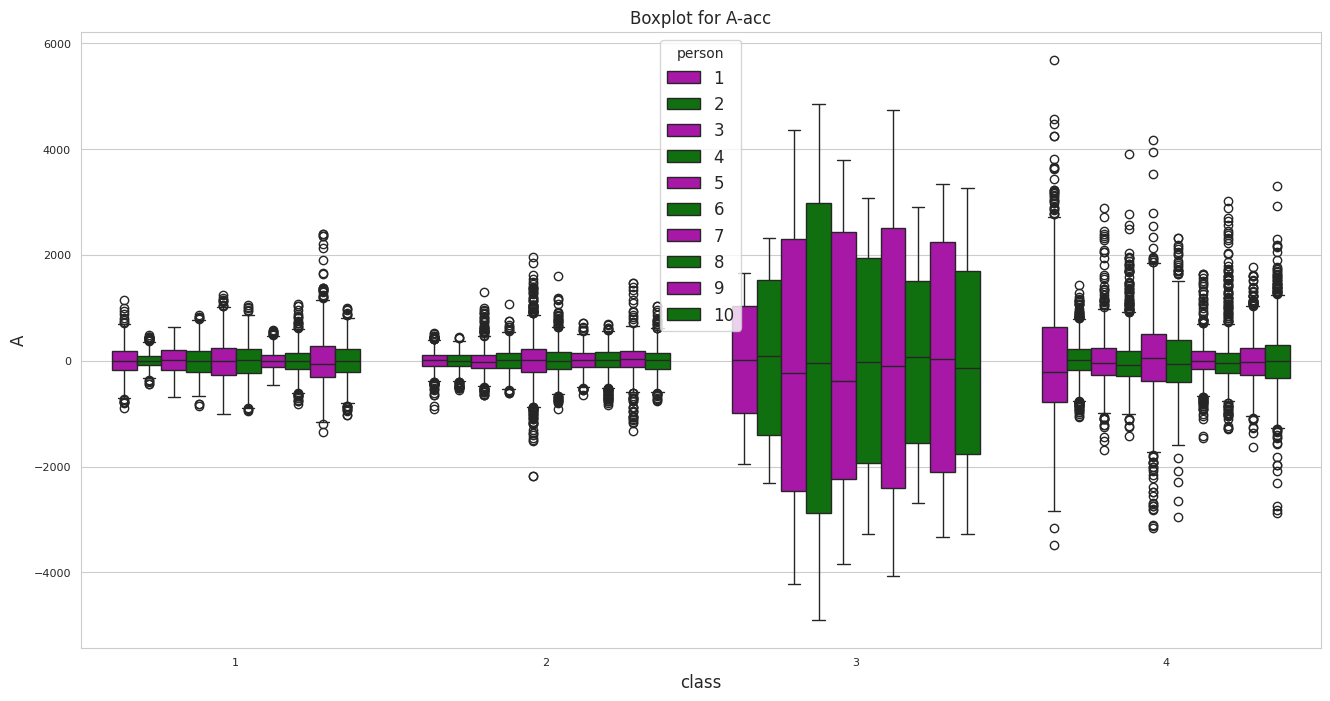

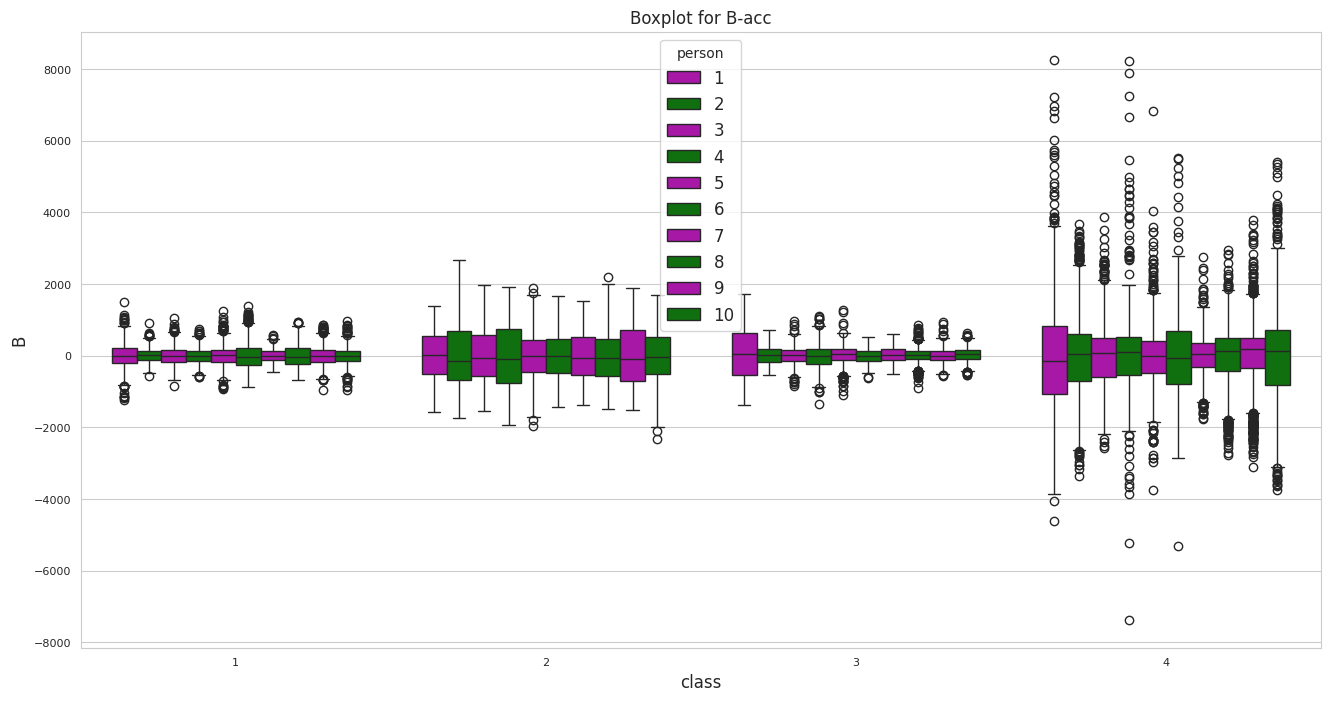

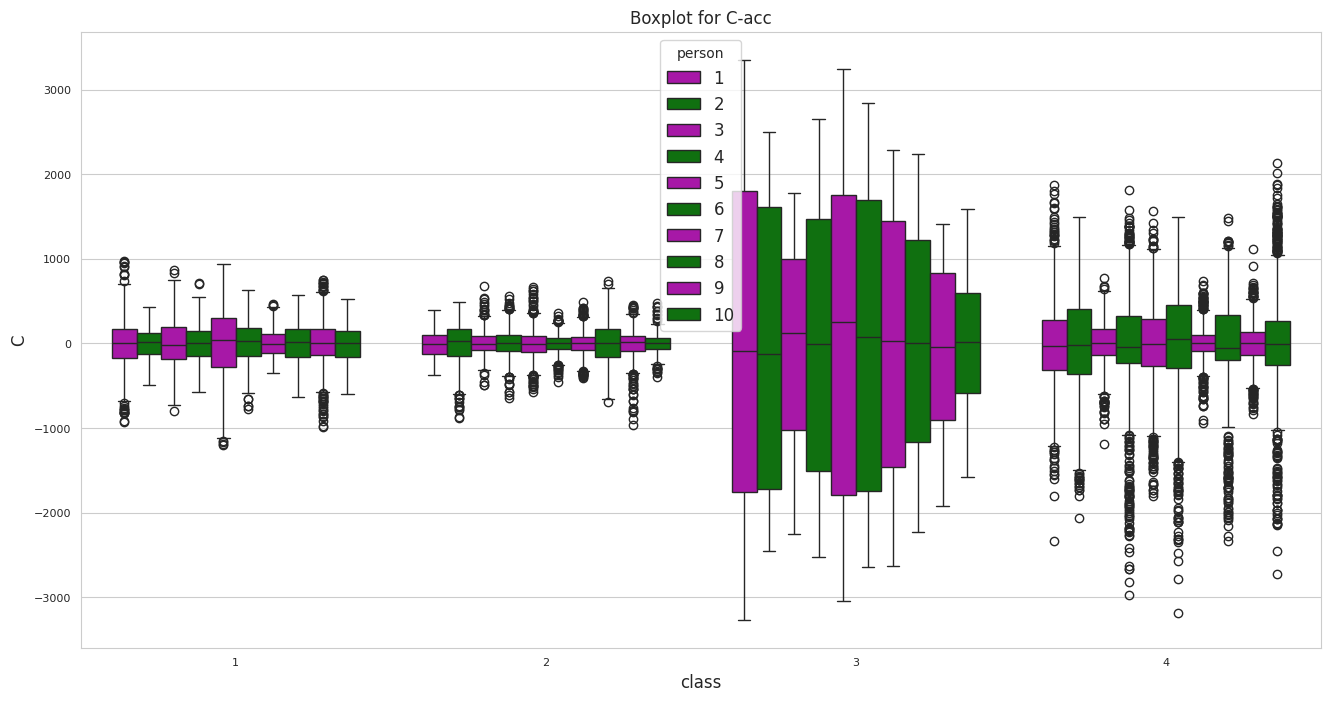

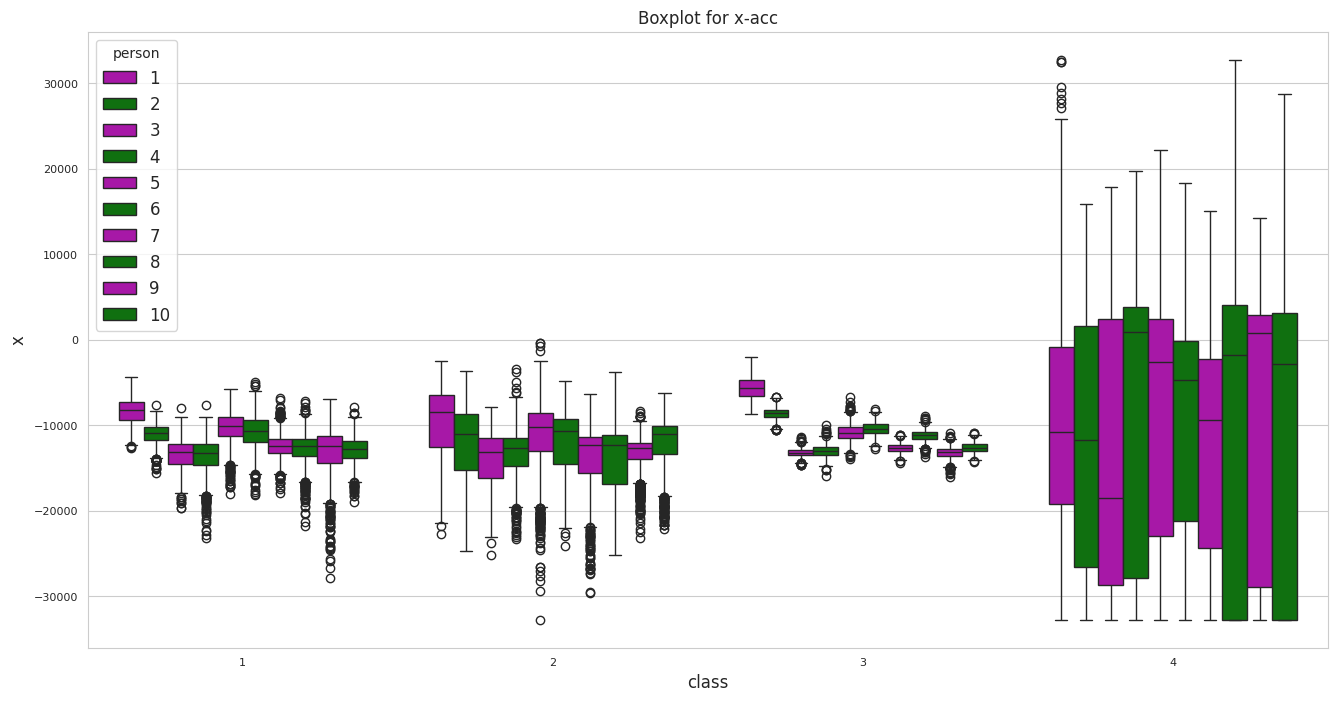

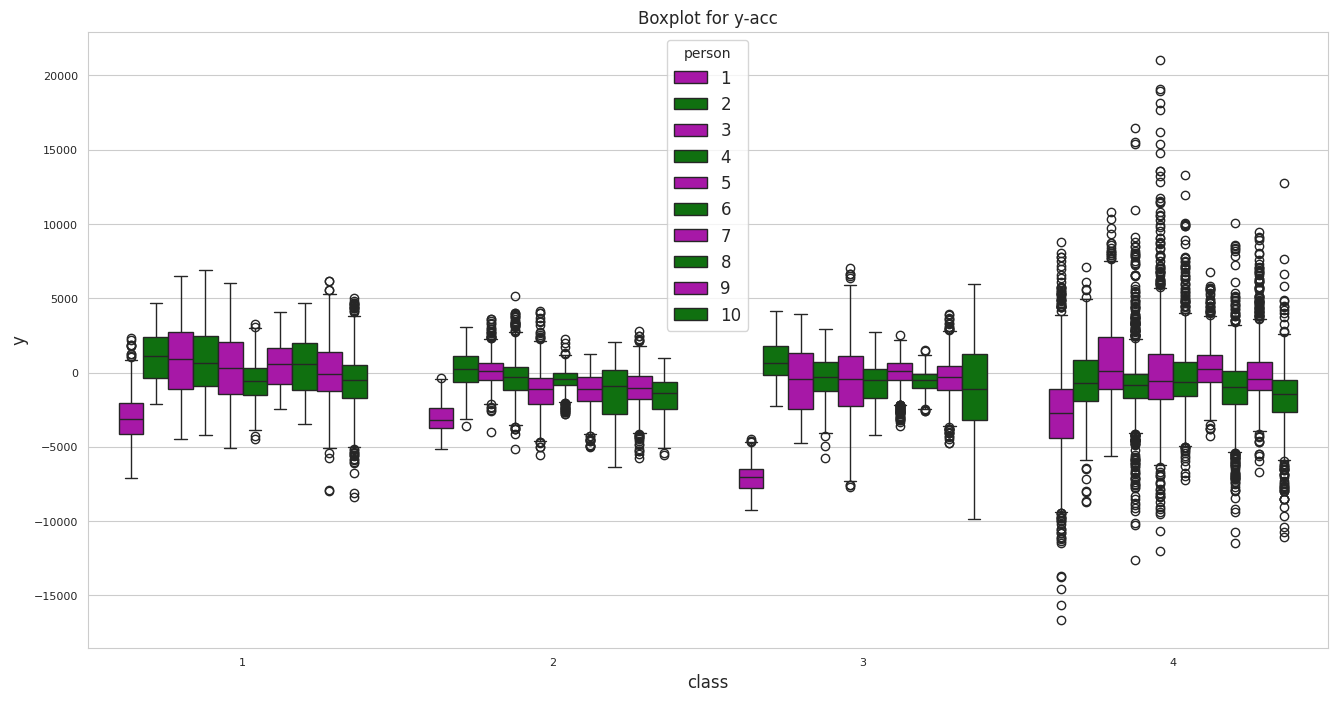

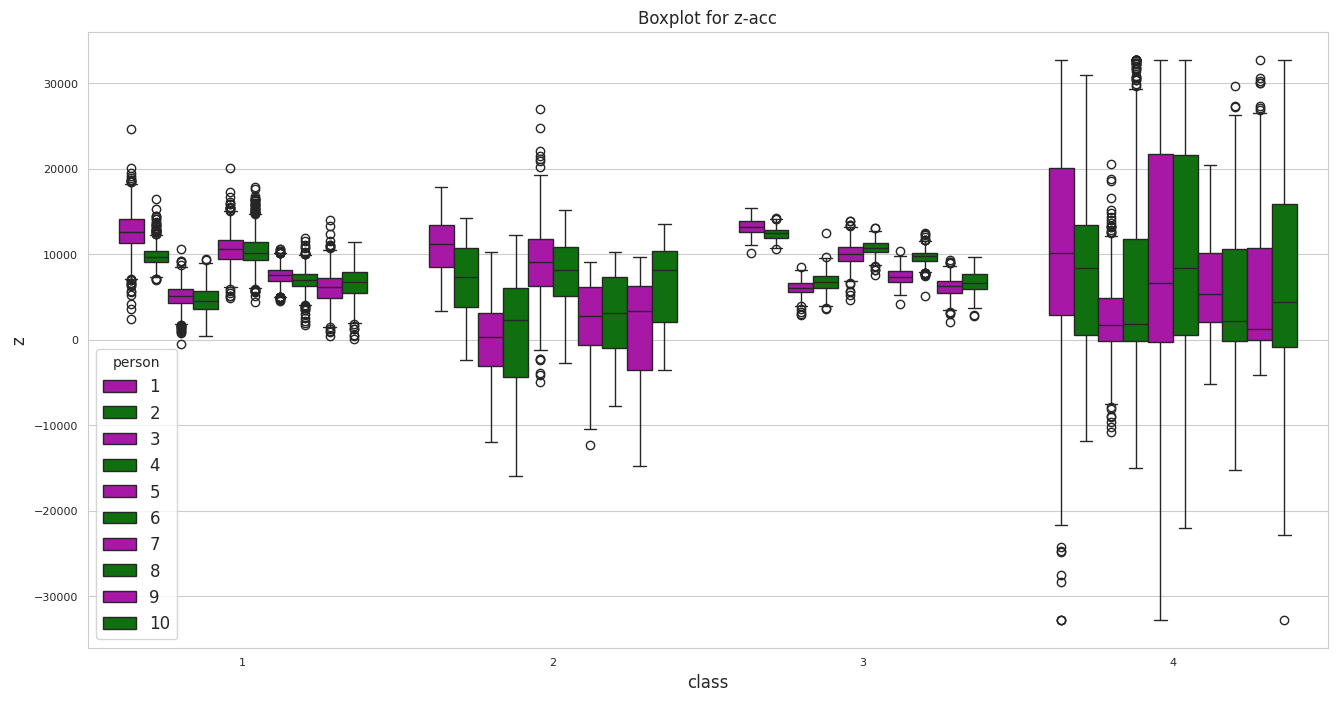

In [ ]:
#Se realiza un análisis estadístico de las señales usando boxplots
#Se muestra la distribución de cada variable respecto a cada clase y respecto a cada persona
plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="A",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for A-acc")
plt.show()

plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="B",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for B-acc")
plt.show()


plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="C",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for C-acc")
plt.show()


plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="x",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for x-acc")
plt.show()


plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="y",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for y-acc")
plt.show()


plt.figure(figsize=(16,8))
sns.boxplot(x="class", y="z",
            hue="person", palette=["m", "g"],
            data=df)
plt.title("Boxplot for z-acc")
plt.show()

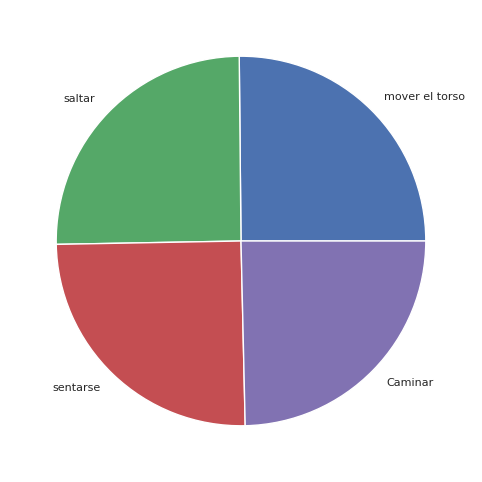

In [ ]:
plt.figure(figsize=(12,6))
plt.pie(df['class'].value_counts(), labels=[index_label[x] for x in df['class'].value_counts().index]) #Gráfica de torta para observar la cantidad de datos de cada clase, que en general es parecida pero hay un pequeño desbalance por la forma en que se tomaron los datos
plt.show()

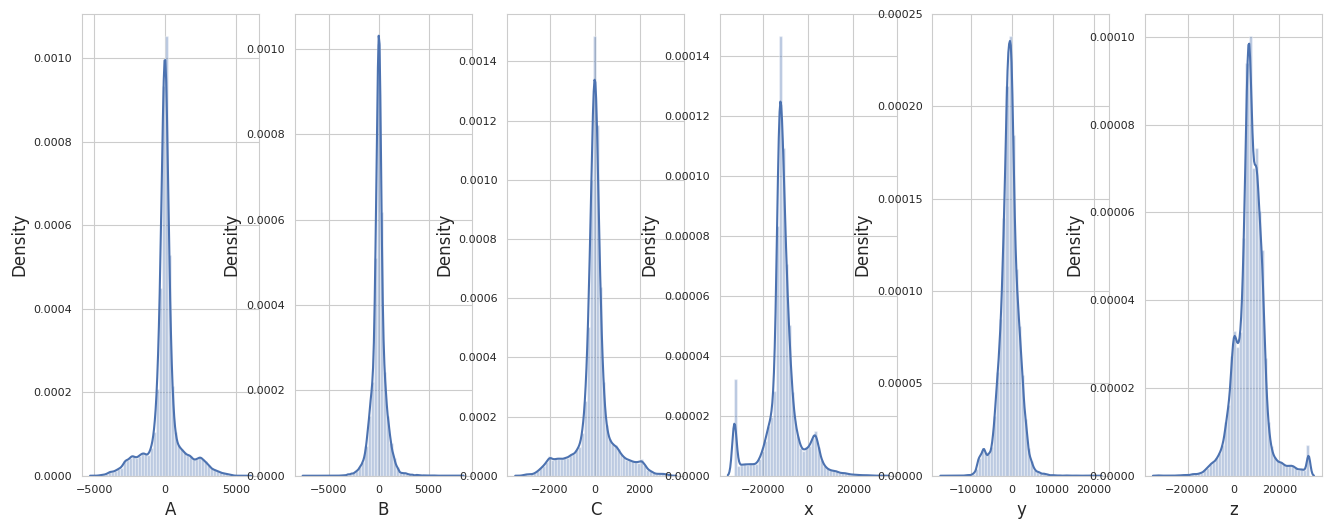

In [ ]:
# Se realizan gráficos de distribución de cada variable medida, (Densidad de probabilidad)
plt.figure(figsize=(16,6))
plt.subplot(1,6,1)
sns.distplot(df['A'])

plt.subplot(1,6,2)
sns.distplot(df['B'])

plt.subplot(1,6,3)
sns.distplot(df['C'])

plt.subplot(1,6,4)
sns.distplot(df['x'])

plt.subplot(1,6,5)
sns.distplot(df['y'])

plt.subplot(1,6,6)
sns.distplot(df['z'])
plt.show()

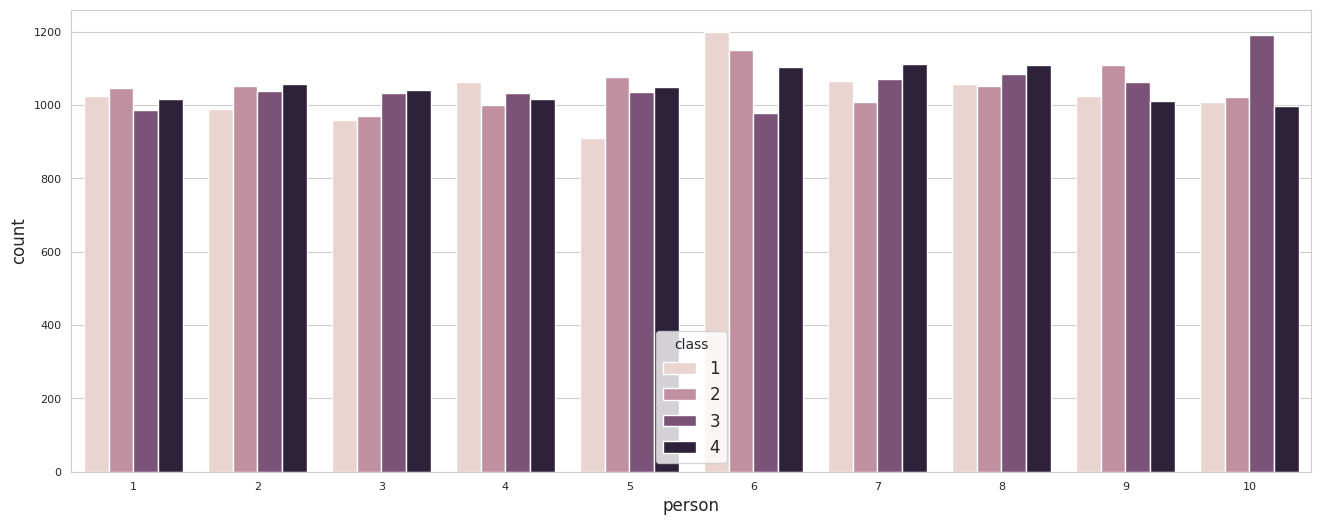

In [ ]:
plt.figure(figsize=(16,6))
sns.countplot(x='person', hue='class', data=df)#Gráfico para identificar la cantidad de muestras por persona para cada clase, donde se observa un desbalance en la cantidad de muestras
plt.show()

In [ ]:
df = df[~df["class"].isin([0])] #Se elimina la clase 0 porque no se tomaron datos para un estado neutro sin actividades
print("Remaining classes",df['class'].unique())

Remaining classes [1 2 3 4]


In [ ]:
X_train = df[df['person'] <= 7] #Se separan los datos para entrenamiento con las primeras 7 personas
X_test = df[df['person'] > 7] #Se separan los datos para test con las 3 personas restantes
y_train = X_train.pop('class') #Se elimina la columna "class" de X_train y se coloca en y_train
y_test = X_test.pop('class') #Se elimina la columna "class" de X_test y se coloca en y_test
X_train.head() #X_train sin la columna "class"

,A,B,C,x,y,z,person
0,-273,-78,194,-8209,-1143,11831,1
1,-73,41,89,-7782,-1408,13763,1
2,-73,-284,1,-8543,-1266,13596,1
3,48,-306,-79,-9315,-1725,12990,1
4,98,-130,-175,-11340,-2315,12269,1


In [ ]:
X_train.drop('person', axis=1, inplace=True)#Se elimina la columna "person" ya que no se necesita para el entrenamiento
X_test.drop('person', axis=1, inplace=True)#Se elimina la columna "person"
X_train.head()

,A,B,C,x,y,z
0,-273,-78,194,-8209,-1143,11831
1,-73,41,89,-7782,-1408,13763
2,-73,-284,1,-8543,-1266,13596
3,48,-306,-79,-9315,-1725,12990
4,98,-130,-175,-11340,-2315,12269


In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, #Se analizan los tamaños de los grupos de datos

((29087, 6), (29087,), (12733, 6), (12733,))

In [ ]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train) #Se calculan los pesos de cada clase debido al desbalance de datos
train_class_weights = dict(zip(np.unique(y_train), weights)) #Crea un diccionario con las clases y el respectivo peso de cada una
pprint(train_class_weights)

{1: 1.0082848031059346,
 2: 0.9959936994932201,
 3: 1.012919626688954,
 4: 0.9833333333333333}


In [ ]:
scaler = skp.MinMaxScaler() #Se define el objeto scaler
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns) #Se escalan los datos de cada columna de entrenamiento para que queden entre 0 y 1 dependiendo del rango encontrado por fit para cada columna
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns) #Se escalan los datos de de cada columna de test con el mismo rango de X_train
X_test.shape #Muestra que se mantiene la cantidad de datos pero escalada

(12733, 6)

In [ ]:
dtc = skt.DecisionTreeClassifier(random_state=seed, class_weight=train_class_weights)#Se crea el clasificador de árbol de decisión con los pesos de cada clase y una semilla 100 para obtener resultados iguales cada vez que se ejecute el notebook
dtc.fit(X_train, y_train)#Se realiza el entrenamiento a partir de X_train como entradas y y_train como salidas esperadas
predictions = dtc.predict(X_test) #Se ejecuta el modelo con datos de X_test de las ultimas 3 personas con las cuales no se entreno el modelo
skm.accuracy_score(y_test, predictions) #Se comparan las predicciones hechas al ejecutar el modelo con y_test que sería la salida real esperada, obteniendo un 81.4% de precisión

0.8144192256341789

In [ ]:
from sklearn.metrics import confusion_matrix
predictions_tr = dtc.predict(X_train)
confusion_matrix(y_train, predictions_tr) #Se genera la matriz de confusión para los datos de entrenamiento, y tal como se esperaba, se obtiene un resultado perfecto

array([[7212,    0,    0,    0],
       [   0, 7301,    0,    0],
       [   0,    0, 7179,    0],
       [   0,    0,    0, 7395]])

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions) #Se genera la matriz de confusión para los datos de prueba, donde ya se obtienen errores de detección, sin embargo, la mayor parte de las detecciones estan en la diagonal de la matriz, lo que indica un buen funcionamiento del modelo

array([[1958,  584,  341,  208],
       [ 412, 2520,   30,  222],
       [ 292,  108, 2851,   89],
       [  11,   52,   14, 3041]])

In [ ]:
rfc = ske.RandomForestClassifier(random_state=seed, class_weight=train_class_weights) #Ahora se entrena un modelo random forest
rfc.fit(X_train, y_train)
predictions = rfc.predict(X_test)
skm.accuracy_score(y_test, predictions)#Se obtiene un 87% de precisión respecto a los datos de prueba

0.869865703290662

In [ ]:
from sklearn.metrics import confusion_matrix
predictions_tr = rfc.predict(X_train)
confusion_matrix(y_train, predictions_tr)

array([[7212,    0,    0,    0],
       [   0, 7301,    0,    0],
       [   0,    0, 7179,    0],
       [   0,    0,    0, 7395]])

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions) #La mayor parte de las detecciones se encuentran en la diagonal de la matriz, lo que indica un buen funcionamiento del modelo

array([[2340,  452,  209,   90],
       [ 440, 2692,   20,   32],
       [ 336,   39, 2957,    8],
       [   7,   17,    7, 3087]])

In [ ]:
import pickle
filename = 'finalized_model_dt_pickle.pkl'
pickle.dump(dtc, open(filename, 'wb')) #Se guarda el modelo árbol de decisión como un .pkl

In [ ]:
import joblib
filename = 'finalized_model_dt_joblib.sav'
joblib.dump(dtc, filename) #Se guarda el modelo árbol de decisión como un .sav

In [ ]:
import pickle
filename = 'finalized_model_rf_pickle.pkl'
pickle.dump(rfc, open(filename, 'wb')) #Se guarda el modelo random forest como un .pkl

In [ ]:
import joblib
filename = 'finalized_model_rf_joblib.sav'
joblib.dump(rfc, filename) #Se guarda el modelo random forest como un .sav